In [1]:
# ==============================================================================
# BƯỚC 2 / DEEP EDA & FEATURE ENGINEERING
# Khám phá đặc trưng, xử lý nhiễu ngữ cảnh và chế tạo biến mới
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ chuyên nghiệp
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
processed_dir = r'D:\Ds108\Lab4\processed_data'

# Chỉ dùng Tập A (Tháng 4-6) để làm EDA nhằm tránh Data Leakage từ tương lai (Tập B)
df_A = pd.read_parquet(f'{processed_dir}\\dataset_A_tidy.parquet')
df_B = pd.read_parquet(f'{processed_dir}\\dataset_B_tidy.parquet')

# Tiền tính toán Lead Time cho EDA
df_A['planned_lead_time'] = (df_A['VSD'] - df_A['Order_date']).dt.days
df_B['planned_lead_time'] = (df_B['VSD'] - df_B['Order_date']).dt.days

print("Load data thanh cong!")
print(f"Tap A (EDA & Fit): {df_A.shape}")
print(f"Tap B (Transform): {df_B.shape}")

Load data thanh cong!
Tap A (EDA & Fit): (399053, 29)
Tap B (Transform): (1074897, 29)


------------------------------------------------------------
[1] CLASS IMBALANCE DETECTOR
------------------------------------------------------------


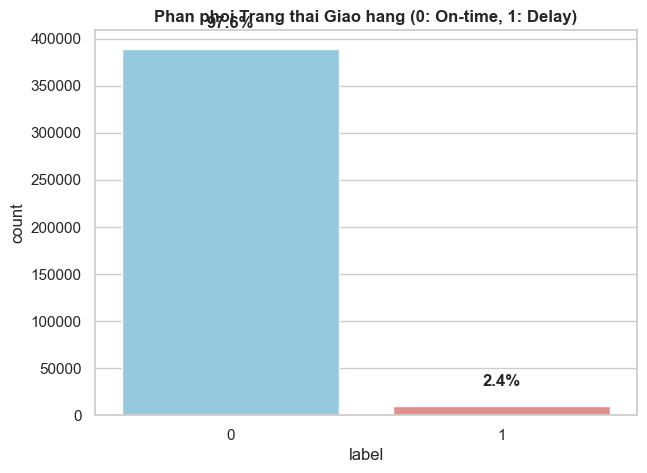

So don dung han : 389320
So don tre han  : 9733
==> KET LUAN: Lop da so gap 40.0 lan lop thieu so.
==> VAI TRO: Chung minh data bi Extreme Imbalance. Vo hieu hoa Accuracy, bat buoc dung Macro F1 va setup tham so scale_pos_weight trong mo hinh.


In [3]:
# -----------------------------------------------------------
# 1. PHÂN TÍCH ĐƠN BIẾN: CLASS IMBALANCE (Sai lệch phân phối nhãn)
# -----------------------------------------------------------
def detect_class_imbalance(df):
    print("-" * 60)
    print("[1] CLASS IMBALANCE DETECTOR")
    print("-" * 60)
    
    plt.figure(figsize=(7, 5))
    ax = sns.countplot(data=df, x='label', palette=['skyblue', 'lightcoral'])
    plt.title("Phan phoi Trang thai Giao hang (0: On-time, 1: Delay)", fontweight='bold')
    
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%\n'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')
    plt.show()
    
    delay_count = df['label'].sum()
    ontime_count = total - delay_count
    ratio = ontime_count / delay_count
    
    print(f"So don dung han : {ontime_count}")
    print(f"So don tre han  : {delay_count}")
    print(f"==> KET LUAN: Lop da so gap {ratio:.1f} lan lop thieu so.")
    print("==> VAI TRO: Chung minh data bi Extreme Imbalance. Vo hieu hoa Accuracy, bat buoc dung Macro F1 va setup tham so scale_pos_weight trong mo hinh.")

detect_class_imbalance(df_A)

------------------------------------------------------------
[2] DOMAIN LOGIC: PLANNED LEAD TIME OUTLIERS
------------------------------------------------------------
VẤN ĐỀ: Thống kê IQR sẽ xóa nhầm các đơn dự án (Lead time > 40 ngày).
- Phát hiện 0 đơn có Lead Time âm (VSD < Order_date -> Lỗi Data Entry).
- Phát hiện 19897 đơn có Lead Time > 90 ngày (Hợp lệ trong Supply Chain).


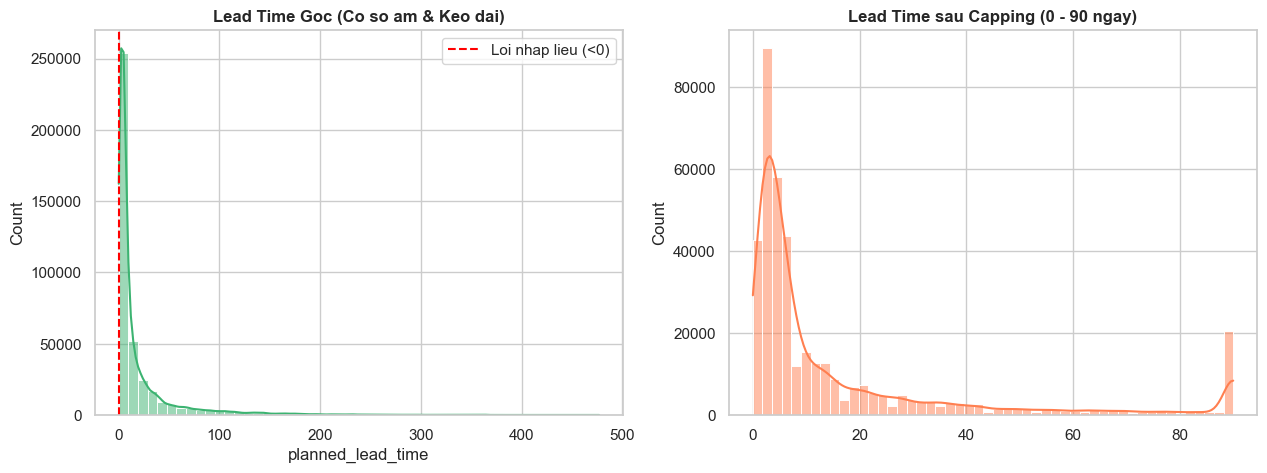

==> GIẢI PHÁP: Capping bằng Domain Knowledge [0, 90] thay vì IQR để không làm mất hành vi đặt hàng dài hạn.


In [4]:
# -----------------------------------------------------------
# 2. PHÂN TÍCH ĐƠN BIẾN: TIME OUTLIERS VS DOMAIN KNOWLEDGE
# -----------------------------------------------------------
def analyze_lead_time_outliers(df):
    print("-" * 60)
    print("[2] DOMAIN LOGIC: PLANNED LEAD TIME OUTLIERS")
    print("-" * 60)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Biểu đồ gốc
    sns.histplot(df['planned_lead_time'].dropna(), bins=50, color='mediumseagreen', kde=True, ax=axes[0])
    axes[0].set_title('Lead Time Goc (Co so am & Keo dai)', fontweight='bold')
    axes[0].axvline(0, color='red', linestyle='--', label='Loi nhap lieu (<0)')
    axes[0].legend()
    
    negative_lt = df[df['planned_lead_time'] < 0].shape[0]
    super_long_lt = df[df['planned_lead_time'] > 90].shape[0]
    
    print("VẤN ĐỀ: Thống kê IQR sẽ xóa nhầm các đơn dự án (Lead time > 40 ngày).")
    print(f"- Phát hiện {negative_lt} đơn có Lead Time âm (VSD < Order_date -> Lỗi Data Entry).")
    print(f"- Phát hiện {super_long_lt} đơn có Lead Time > 90 ngày (Hợp lệ trong Supply Chain).")
    
    # Mô phỏng Capping
    temp_lt = np.where(df['planned_lead_time'] < 0, 0, df['planned_lead_time'])
    temp_lt = np.where(temp_lt > 90, 90, temp_lt)
    
    sns.histplot(temp_lt, bins=50, color='coral', kde=True, ax=axes[1])
    axes[1].set_title('Lead Time sau Capping (0 - 90 ngay)', fontweight='bold')
    plt.show()
    
    print("==> GIẢI PHÁP: Capping bằng Domain Knowledge [0, 90] thay vì IQR để không làm mất hành vi đặt hàng dài hạn.")

analyze_lead_time_outliers(df_A)

------------------------------------------------------------
[3] SPARSE METADATA: GOM NHÓM SUPPLIER_CD HIẾM
------------------------------------------------------------


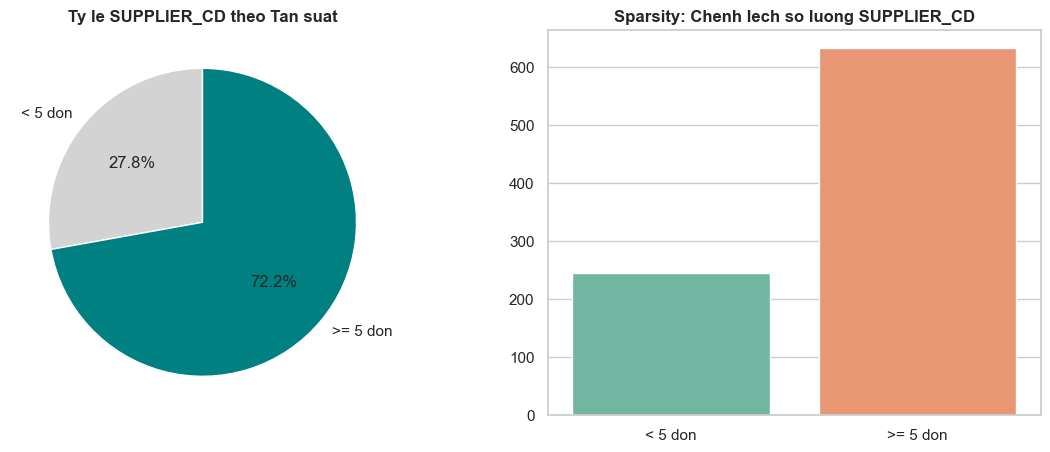

VẤN ĐỀ: Phát hiện 244 SUPPLIER_CD (chiếm 27.8%) chỉ xuất hiện dưới 5 lần.
==> GIẢI PHÁP: Gom nhóm thành 'RARE_ENTITY' để thu gọn không gian Vector, tránh Lời nguyền số chiều (Curse of Dimensionality) và chống Overfit cho Cây quyết định.


In [5]:
# -----------------------------------------------------------
# 3. PHÂN TÍCH THỰC THỂ HIẾM (DIMENSIONALITY REDUCTION)
# -----------------------------------------------------------
def analyze_sparse_metadata(df, col='SUPPLIER_CD', threshold=5):
    print("-" * 60)
    print(f"[3] SPARSE METADATA: GOM NHÓM {col} HIẾM")
    print("-" * 60)
    
    counts = df[col].value_counts()
    rare_count = counts[counts < threshold].shape[0]
    popular_count = counts[counts >= threshold].shape[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].pie([rare_count, popular_count], labels=[f'< {threshold} don', f'>= {threshold} don'], 
                autopct='%1.1f%%', colors=['lightgray', 'teal'], startangle=90)
    axes[0].set_title(f'Ty le {col} theo Tan suat', fontweight='bold')
    
    sns.barplot(x=[f'< {threshold} don', f'>= {threshold} don'], y=[rare_count, popular_count], ax=axes[1], palette='Set2')
    axes[1].set_title(f'Sparsity: Chenh lech so luong {col}', fontweight='bold')
    plt.show()
    
    print(f"VẤN ĐỀ: Phát hiện {rare_count} {col} (chiếm {rare_count/len(counts)*100:.1f}%) chỉ xuất hiện dưới {threshold} lần.")
    print("==> GIẢI PHÁP: Gom nhóm thành 'RARE_ENTITY' để thu gọn không gian Vector, tránh Lời nguyền số chiều (Curse of Dimensionality) và chống Overfit cho Cây quyết định.")

analyze_sparse_metadata(df_A, 'SUPPLIER_CD', 5)

------------------------------------------------------------
[4] BIVARIATE ANALYSIS: ĐỘ LỆCH TƯƠNG TÁC (INTERACTION BIAS)
------------------------------------------------------------


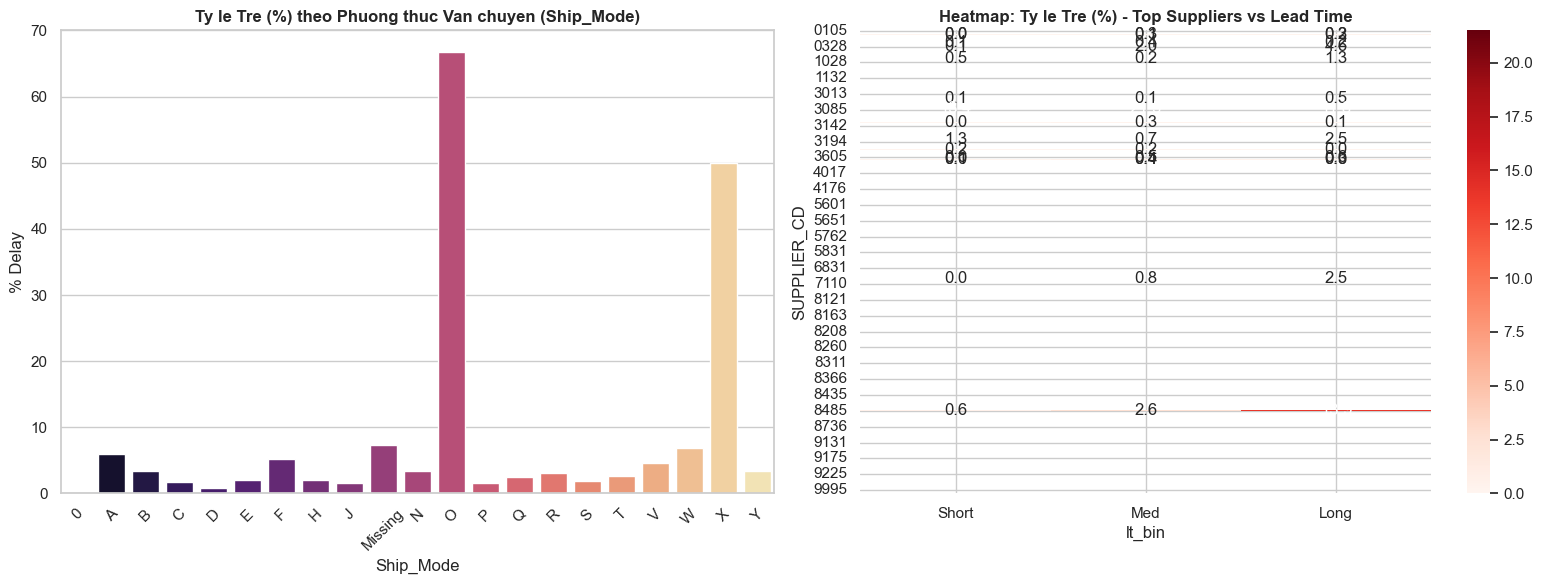

VẤN ĐỀ: Tỉ lệ trễ không rải đều mà tập trung cục bộ vào một vài Ship Mode cụ thể, hoặc phụ thuộc vào độ gấp (Lead time) của từng Supplier.
==> GIẢI PHÁP: Chế tạo biến tổ hợp (Feature Crossing) để ép mô hình chú ý vào các Micro-segments này.


In [6]:
# -----------------------------------------------------------
# 4. PHÂN TÍCH ĐA BIẾN (TƯƠNG TÁC GÂY TRỄ HẠN)
# -----------------------------------------------------------
def analyze_bivariate_interactions(df):
    print("-" * 60)
    print("[4] BIVARIATE ANALYSIS: ĐỘ LỆCH TƯƠNG TÁC (INTERACTION BIAS)")
    print("-" * 60)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 4.1 Ship Mode vs Delay
    if 'Ship_Mode' in df.columns:
        target_rate = df.groupby('Ship_Mode')['label'].mean().sort_values(ascending=False) * 100
        sns.barplot(x=target_rate.index, y=target_rate.values, palette='magma', ax=axes[0])
        axes[0].set_title('Ty le Tre (%) theo Phuong thuc Van chuyen (Ship_Mode)', fontweight='bold')
        axes[0].set_ylabel('% Delay')
        axes[0].tick_params(axis='x', rotation=45)
    
    # 4.2 Lead time bins vs Delay (Micro-segments)
    top_supps = df['SUPPLIER_CD'].value_counts().head(15).index
    df_top = df[df['SUPPLIER_CD'].isin(top_supps)].copy()
    df_top['lt_bin'] = pd.qcut(df_top['planned_lead_time'], q=3, labels=['Short', 'Med', 'Long'])
    
    pivot = df_top.groupby(['SUPPLIER_CD', 'lt_bin'])['label'].mean().unstack() * 100
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", ax=axes[1])
    axes[1].set_title('Heatmap: Ty le Tre (%) - Top Suppliers vs Lead Time', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("VẤN ĐỀ: Tỉ lệ trễ không rải đều mà tập trung cục bộ vào một vài Ship Mode cụ thể, hoặc phụ thuộc vào độ gấp (Lead time) của từng Supplier.")
    print("==> GIẢI PHÁP: Chế tạo biến tổ hợp (Feature Crossing) để ép mô hình chú ý vào các Micro-segments này.")

analyze_bivariate_interactions(df_A)

In [8]:
# -----------------------------------------------------------
# 5. FEATURE ENGINEERING PIPELINE (Áp dụng các giải pháp từ EDA)
# -----------------------------------------------------------
def feature_engineering_pipeline(df_train, df_test=None):
    """
    Fit trên tập Train (A) và Transform trên tập Test (B) để chống Data Leakage.
    """
    def transform_df(df, is_train=False, stats=None):
        d = df.copy()
        
        # 1. TIME FEATURES (Vectorized)
        d['order_month'] = d['Order_date'].dt.month
        d['order_dayofweek'] = d['Order_date'].dt.dayofweek
        d['order_is_weekend'] = d['order_dayofweek'].isin([5, 6]).astype(int)
        
        d['vsd_month'] = d['VSD'].dt.month
        d['vsd_is_weekend'] = d['VSD'].dt.dayofweek.isin([5, 6]).astype(int)
        
        # Capping Lead Time theo Domain Knowledge
        d['planned_lead_time'] = (d['VSD'] - d['Order_date']).dt.days
        d['planned_lead_time'] = np.where(d['planned_lead_time'] < 0, 0, d['planned_lead_time'])
        d['planned_lead_time'] = np.where(d['planned_lead_time'] > 90, 90, d['planned_lead_time'])
        d['planned_lead_time'] = d['planned_lead_time'].fillna(0)
        
        # 2. RARE ENTITY HANDLING & FREQUENCY ENCODING
        high_card_cols = ['SUPPLIER_CD', 'PRODUCT_CD', 'BRAND_CD']
        
        # Chỉ học phân phối trên tập Train
        if is_train:
            stats = {'freq': {}, 'rare': {}}
            for col in high_card_cols:
                counts = d[col].value_counts()
                stats['freq'][col] = counts.to_dict()
                stats['rare'][col] = set(counts[counts < 5].index.tolist()) # Set lookup nhanh
                
        # Áp dụng cho cả Train và Test (Nằm NGOÀI if is_train)
        for col in high_card_cols:
            # FIX LỖI CATEGORY TẠI ĐÂY
            if 'RARE' not in d[col].cat.categories:
                d[col] = d[col].cat.add_categories(['RARE'])
                
            # TỐI ƯU SIÊU TỐC: Dùng mask và isin
            d[col] = d[col].mask(d[col].isin(stats['rare'][col]), 'RARE')
            d[f'{col}_freq_count'] = d[col].map(stats['freq'][col]).fillna(0)
            
        # 3. FEATURE CROSSING
        d['Supplier_cross_Brand'] = d['SUPPLIER_CD'].astype(str) + "_" + d['BRAND_CD'].astype(str)
        d['Supplier_cross_Brand'] = d['Supplier_cross_Brand'].astype('category')
        
        d['ShipMode_cross_Weekend'] = d['Ship_Mode'].astype(str) + "_" + d['vsd_is_weekend'].astype(str)
        d['ShipMode_cross_Weekend'] = d['ShipMode_cross_Weekend'].astype('category')
        
        # 4. DỌN DẸP DATETIME
        d = d.drop(columns=['Order_date', 'VSD'])
        
        return d, stats

    # ========================================================
    # THỰC THI PIPELINE
    # ========================================================
    print("Engineering tap Train (A)...")
    train_fe, learned_stats = transform_df(df_train, is_train=True)
    
    if df_test is not None:
        print("Engineering tap Test (B)...")
        test_fe, _ = transform_df(df_test, is_train=False, stats=learned_stats)
        return train_fe, test_fe
        
    return train_fe

# Gọi hàm
df_A_fe, df_B_fe = feature_engineering_pipeline(df_A, df_B)

# Lưu dữ liệu
fe_dir = r'D:\Ds108\Lab4\processed_data'
import os
if not os.path.exists(fe_dir):
    os.makedirs(fe_dir)
    
df_A_fe.to_parquet(f'{fe_dir}\\dataset_A_fe.parquet', index=False)
df_B_fe.to_parquet(f'{fe_dir}\\dataset_B_fe.parquet', index=False)

print("\n=> [Hoan Thanh] Notebook 2: Deep EDA & FE da xong. San sang tien vao Modeling (Notebook 3)!")

Engineering tap Train (A)...
Engineering tap Test (B)...

=> [Hoan Thanh] Notebook 2: Deep EDA & FE da xong. San sang tien vao Modeling (Notebook 3)!
